# Stock Financial Analysis Dashboard: Analytical Notebook

## Project Overview
This notebook presents the analytical workflow behind a stock financial analysis product.

The product is designed for:
- beginner investors
- accounting and finance students

It helps users review a company's historical financial performance through:
- revenue and net income trends
- profitability and leverage indicators
- earnings per share
- a simple forecast

## Analytical Problem
Many beginner users find raw financial statement data difficult to interpret.
This project addresses that problem by transforming financial data into a more user-friendly format with summary metrics, charts, and a simple forecast.

## Data Source and Scope

The intended data source for this project is WRDS Compustat.  
Because live access may not always be available during evaluation, this notebook demonstrates the workflow using sample fallback data with a similar structure.  
Source acknowledged: WRDS Compustat.  
Accessed / prepared for this assignment in April 2026.

### Variables Used
- Revenue
- Net Income
- ROE
- Total Assets
- Total Liabilities
- Stock Price
- Shares Outstanding

These variables were selected because they support basic analysis of:
- profitability
- leverage
- earnings
- historical performance trends

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Analysis Settings

In the Streamlit app version, users can choose the stock ticker, start year, forecast horizon, and assumed annual growth rate.

In this notebook, fixed values are used to clearly demonstrate the analytical workflow.

In [2]:
ticker = "AAPL"
start_year = 2018
n_years = 3
growth_rate = 5.0

## Data Loading

To keep this notebook stable and easy to evaluate, a sample dataset is generated for demonstration.
This allows the notebook to show the full analytical process from raw data to output.

In [3]:
def generate_sample_data(start_year):
    np.random.seed(42)
    years = list(range(start_year, 2024))
    
    if len(years) == 0:
        years =   [2023]

    revenue = np.linspace(180, 380, len(years)) + np.random.uniform(-20, 20, len(years))
    net_income = revenue * np.random.uniform(0.12, 0.22, len(years))
    total_assets = np.linspace(350, 850, len(years)) + np.random.uniform(-40, 40, len(years))
    total_liabilities = total_assets * np.random.uniform(0.28, 0.48, len(years))
    stock_price = np.linspace(70, 220, len(years)) + np.random.uniform(-15, 15, len(years))
    shares_outstanding = np.random.uniform(12, 20, len(years))
    roe = np.random.uniform(14, 28, len(years))

    df = pd.DataFrame({
        "Year": years,
        "Revenue": revenue,
        "Net_Income": net_income,
        "ROE": roe,
        "Total_Assets": total_assets,
        "Total_Liabilities": total_liabilities,
        "Stock_Price": stock_price,
        "Shares_Outstanding": shares_outstanding
    })

    return df.round(2)

raw_df = generate_sample_data(start_year)
raw_df.head()

,Year,Revenue,Net_Income,ROE,Total_Assets,Total_Liabilities,Stock_Price,Shares_Outstanding
0,2018,174.98,22.01,18.26,376.60,137.98,68.68,16.86
1,2019,238.03,49.18,15.37,426.99,144.43,108.56,13.36
2,2020,269.28,48.50,23.58,524.55,211.06,120.99,12.52
3,2021,303.95,58.00,20.16,624.67,192.34,160.43,19.59
4,2022,326.24,39.82,15.71,734.34,248.52,192.77,19.73


## Data Cleaning and Preparation

The raw data is cleaned and transformed before analysis.

The preparation steps include:
- converting columns to numeric values
- removing missing observations
- removing invalid zero-denominator rows
- creating derived indicators such as:
  - profit margin
  - debt ratio
  - earnings per share

In [4]:
def prepare_data(df):
    df = df.copy()

    numeric_cols = [
        "Year", "Revenue", "Net_Income", "ROE",
        "Total_Assets", "Total_Liabilities",
        "Stock_Price", "Shares_Outstanding"
    ]

    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.dropna()

    df = df[
        (df["Revenue"] != 0) &
        (df["Total_Assets"] != 0) &
        (df["Shares_Outstanding"] != 0)
    ].copy()

    df["Profit_Margin(%)"] = (df["Net_Income"] / df["Revenue"] * 100).round(2)
    df["Debt_Ratio(%)"] = (df["Total_Liabilities"] / df["Total_Assets"] * 100).round(2)
    df["EPS"] = (df["Net_Income"] / df["Shares_Outstanding"]).round(2)

    return df

df = prepare_data(raw_df)
df.head()

,Year,Revenue,Net_Income,ROE,Total_Assets,Total_Liabilities,Stock_Price,Shares_Outstanding,Profit_Margin(%),Debt_Ratio(%),EPS
0,2018,174.98,22.01,18.26,376.60,137.98,68.68,16.86,12.58,36.64,1.31
1,2019,238.03,49.18,15.37,426.99,144.43,108.56,13.36,20.66,33.83,3.68
2,2020,269.28,48.50,23.58,524.55,211.06,120.99,12.52,18.01,40.24,3.87
3,2021,303.95,58.00,20.16,624.67,192.34,160.43,19.59,19.08,30.79,2.96
4,2022,326.24,39.82,15.71,734.34,248.52,192.77,19.73,12.21,33.84,2.02


## Exploratory Analysis

This section reviews the cleaned dataset and calculates a few simple summary statistics.

The purpose is to convert raw financial data into a more interpretable format for beginner users.

In [5]:
summary_table = pd.DataFrame({
    "Metric": [
        "Average ROE",
        "Average Profit Margin",
        "Average Debt Ratio",
        "Average EPS"
    ],
    "Value": [
        round(df["ROE"].mean(), 2),
        round(df["Profit_Margin(%)"].mean(), 2),
        round(df["Debt_Ratio(%)"].mean(), 2),
        round(df["EPS"].mean(), 2)
    ]
})

summary_table

,Metric,Value
0,Average ROE,19.00
1,Average Profit Margin,17.37
2,Average Debt Ratio,35.11
3,Average EPS,3.02


## Visualisation 1: Stock Price Trend

The first chart shows the historical stock price trend across the selected years.

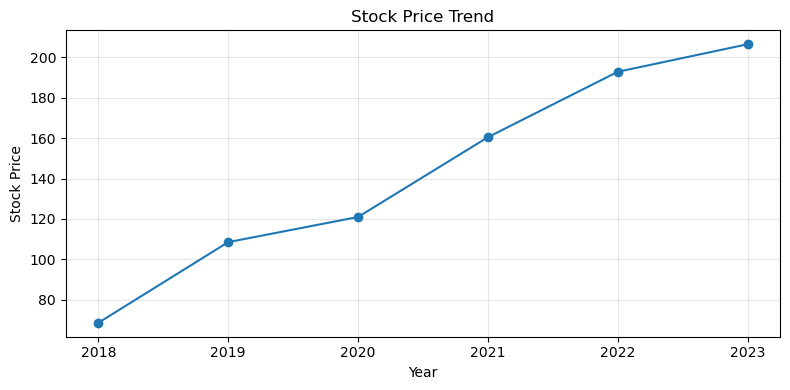

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(df["Year"], df["Stock_Price"], marker="o")
plt.title("Stock Price Trend")
plt.xlabel("Year")
plt.ylabel("Stock Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Visualisation 2: Revenue vs Net Income

The second chart compares revenue and net income over time.
This helps users understand both business scale and profitability.

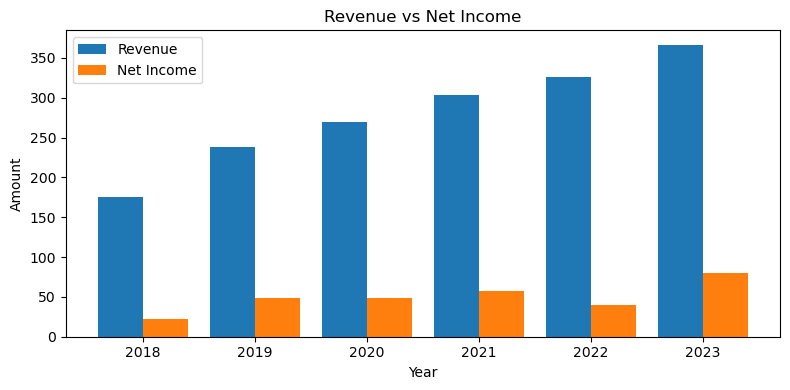

In [7]:
plt.figure(figsize=(8, 4))
plt.bar(df["Year"] - 0.2, df["Revenue"], width=0.4, label="Revenue")
plt.bar(df["Year"] + 0.2, df["Net_Income"], width=0.4, label="Net Income")
plt.title("Revenue vs Net Income")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.tight_layout()
plt.show()

## Simple Forecast

A simple forecast is created by applying a constant annual growth rate to the latest revenue and net income values.

This is included as a product feature demonstration only and should not be interpreted as professional investment advice.

In [8]:
def create_forecast(df, n_years, growth_rate):
    last_year = int(df["Year"].max())
    last_revenue = df["Revenue"].iloc[-1]
    last_income = df["Net_Income"].iloc[-1]

    forecast_df = pd.DataFrame({
        "Year": [last_year + i for i in range(1, n_years + 1)],
        "Forecast_Revenue": [
            last_revenue * (1 + growth_rate / 100) ** i for i in range(1, n_years + 1)
        ],
        "Forecast_Net_Income": [
            last_income * (1 + growth_rate / 100) ** i for i in range(1, n_years + 1)
        ]
    })

    return forecast_df.round(2)

forecast_df = create_forecast(df, n_years, growth_rate)
forecast_df

,Year,Forecast_Revenue,Forecast_Net_Income
0,2024,384.55,83.44
1,2025,403.78,87.62
2,2026,423.97,92.00


## Forecast Visualisation

This chart combines historical and forecast values to produce a more product-oriented output.

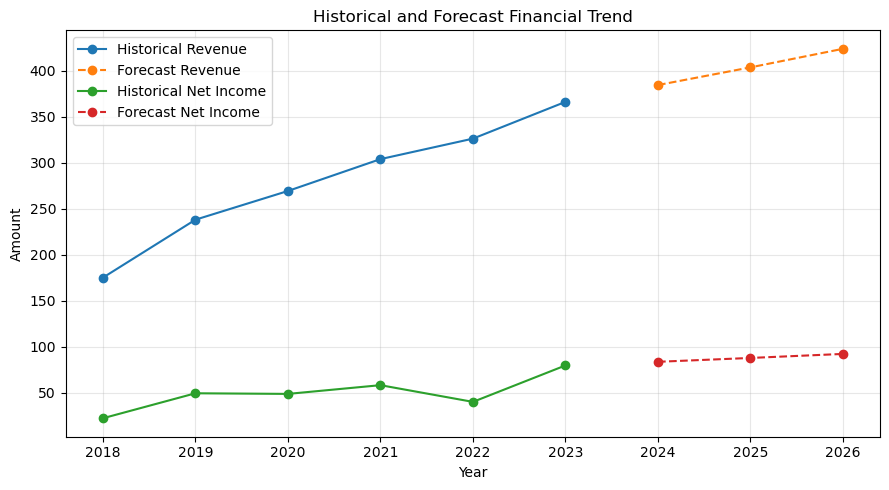

In [9]:
plt.figure(figsize=(9, 5))
plt.plot(df["Year"], df["Revenue"], marker="o", label="Historical Revenue")
plt.plot(forecast_df["Year"], forecast_df["Forecast_Revenue"], marker="o", linestyle="--", label="Forecast Revenue")
plt.plot(df["Year"], df["Net_Income"], marker="o", label="Historical Net Income")
plt.plot(forecast_df["Year"], forecast_df["Forecast_Net_Income"], marker="o", linestyle="--", label="Forecast Net Income")
plt.title("Historical and Forecast Financial Trend")
plt.xlabel("Year")
plt.ylabel("Amount")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Product-Oriented Summary

To make the output easier for non-expert users to understand, a simple rule-based summary is generated from the financial indicators.

In [10]:
def generate_summary(df):
    revenue_first = df["Revenue"].iloc  [0]
    revenue_last = df["Revenue"].iloc[-1]
    roe_avg = df["ROE"].mean()
    margin_avg = df["Profit_Margin(%)"].mean()
    debt_avg = df["Debt_Ratio(%)"].mean()
    eps_avg = df["EPS"].mean()

    revenue_change_pct = ((revenue_last - revenue_first) / revenue_first) * 100

    if revenue_change_pct > 20:
        growth_text = "Revenue shows a strong upward trend over time."
    elif revenue_change_pct > 5:
        growth_text = "Revenue shows moderate growth over time."
    elif revenue_change_pct >= -5:
        growth_text = "Revenue appears relatively stable over time."
    else:
        growth_text = "Revenue shows a declining trend over time."

    if margin_avg >= 15:
        profitability_text = "Profitability appears relatively strong."
    elif margin_avg >= 8:
        profitability_text = "Profitability appears moderate."
    else:
        profitability_text = "Profitability appears relatively weak."

    if debt_avg >= 60:
        debt_text = "Leverage is relatively high."
    elif debt_avg >= 35:
        debt_text = "Leverage is at a moderate level."
    else:
        debt_text = "Leverage is relatively low."

    if roe_avg >= 20 and margin_avg >= 15:
        overall_text = "Overall financial performance appears strong based on these simple indicators."
    elif roe_avg >= 10 and margin_avg >= 8:
        overall_text = "Overall financial performance appears mixed but acceptable."
    else:
        overall_text = "Overall financial performance appears weaker and may require more careful review."

    return {
        "Growth": growth_text,
        "Profitability": profitability_text,
        "Leverage": debt_text,
        "Overall": overall_text,
        "Average ROE": round(roe_avg, 2),
        "Average Profit Margin": round(margin_avg, 2),
        "Average Debt Ratio": round(debt_avg, 2),
        "Average EPS": round(eps_avg, 2)
    }

insight = generate_summary(df)
insight

{'Growth': 'Revenue shows a strong upward trend over time.',
 'Profitability': 'Profitability appears relatively strong.',
 'Leverage': 'Leverage is at a moderate level.',
 'Overall': 'Overall financial performance appears mixed but acceptable.',
 'Average ROE': np.float64(19.0),
 'Average Profit Margin': np.float64(17.37),
 'Average Debt Ratio': np.float64(35.11),
 'Average EPS': np.float64(3.02)}

## Limitations

This notebook has several limitations:

1. The forecast is simplified because it assumes a constant annual growth rate.
2. Sample data is used for demonstration rather than live financial database output.
3. Only a limited number of financial indicators are included.
4. The notebook is intended for educational use and should not be treated as professional investment advice.

## Conclusion

This notebook demonstrates a coherent analytical workflow from data input to final output.

It shows how Python can be used to:
- load or generate financial data
- clean and prepare the data
- create accounting and finance indicators
- visualise historical trends
- generate a simple forecast
- produce a user-oriented summary

This notebook supports the submitted Streamlit data product for Track 4.